# EFHM return periods — how flood depth grows with rarity

A return period expresses how rare a flood is: a 1-in-10-year event is common and
shallow, a 1-in-500-year event is rare and deep. This notebook fetches three
return periods for the same area and compares their depths — one windowed read
per period.

In [1]:
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from pyramids.dataset import Dataset

from earthlens.core import EarthLens

out = Path(tempfile.mkdtemp(prefix="efhm-rp-"))
lat_lim, lon_lim = [51.7, 52.0], [4.6, 5.1]
periods = [10, 100, 500]
paths = EarthLens(
    data_source="jrc-flood",
    lat_lim=lat_lim,
    lon_lim=lon_lim,
    return_periods=periods,
    path=out,
).download()
[p.name for p in paths]

2026-08-09 22:01:03 | INFO | pyramids.base.config | Logging is configured.


2026-08-09 22:01:06.387 | INFO     | earthlens.jrc_flood.backend:_fetch_one:330 - JRCFlood RP10: reading window 601x361 px at (34970, 22960) from https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/CEMS-EFAS/flood_hazard/Europe_RP10_filled_depth.tif


2026-08-09 22:01:07.093 | INFO     | earthlens.jrc_flood.backend:_fetch_one:330 - JRCFlood RP100: reading window 601x361 px at (34970, 22960) from https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/CEMS-EFAS/flood_hazard/Europe_RP100_filled_depth.tif


2026-08-09 22:01:07.556 | INFO     | earthlens.jrc_flood.backend:_fetch_one:330 - JRCFlood RP500: reading window 601x361 px at (34970, 22960) from https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/CEMS-EFAS/flood_hazard/Europe_RP500_filled_depth.tif


['efhm_RP10.tif', 'efhm_RP100.tif', 'efhm_RP500.tif']

## Side-by-side depth maps

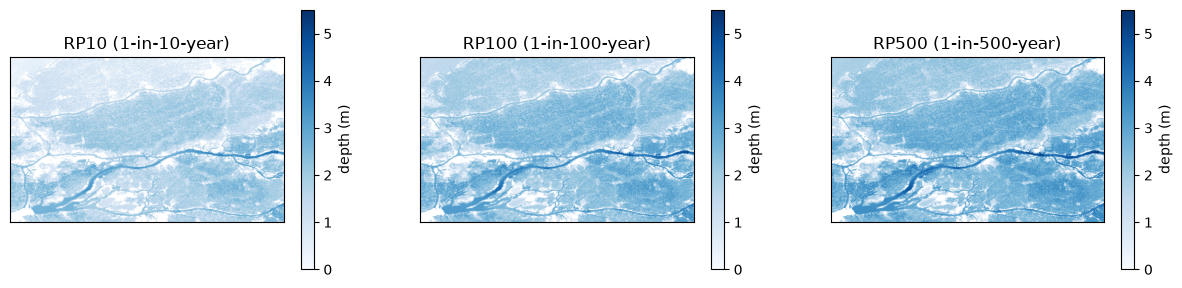

In [2]:
def _depth(path):
    a = Dataset.read_file(str(path)).read_array().astype("float64")
    a[a <= -9999] = np.nan
    return a

depths = [_depth(p) for p in paths]
vmax = np.nanmax([np.nanmax(d) for d in depths])

fig, axes = plt.subplots(1, len(periods), figsize=(5 * len(periods), 4.5))
for ax, rp, d in zip(axes, periods, depths):
    im = ax.imshow(d, cmap="Blues", vmin=0, vmax=vmax)
    ax.set_title(f"RP{rp} (1-in-{rp}-year)")
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, shrink=0.75, label="depth (m)")
plt.show()

## Flooded area and depth grow with the return period

In [3]:
for rp, d in zip(periods, depths):
    flooded = np.isfinite(d).sum()
    print(f"RP{rp:>3}: {flooded:>7,} flooded cells | mean {np.nanmean(d):.2f} m | max {np.nanmax(d):.2f} m")

RP 10: 192,663 flooded cells | mean 1.50 m | max 4.28 m
RP100: 204,126 flooded cells | mean 2.05 m | max 5.10 m
RP500: 206,538 flooded cells | mean 2.30 m | max 5.51 m


## Takeaway

Rarer floods inundate more cells and reach greater depths. Selecting the right
return period lets you match a hazard layer to a design standard (e.g. RP100 for
many flood defences, RP500 for critical infrastructure).